In [3]:
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np 
import pandas as pd 

In [4]:
plt.style.use('fivethirtyeight')

In [5]:
data = sns.load_dataset('tips')

In [6]:
data

,total_bill,tip,sex,smoker,day,time,size
0,16.99,1.01,Female,No,Sun,Dinner,2
1,10.34,1.66,Male,No,Sun,Dinner,3
2,21.01,3.50,Male,No,Sun,Dinner,3
3,23.68,3.31,Male,No,Sun,Dinner,2
4,24.59,3.61,Female,No,Sun,Dinner,4
...,...,...,...,...,...,...,...
239,29.03,5.92,Male,No,Sat,Dinner,3
240,27.18,2.00,Female,Yes,Sat,Dinner,2
241,22.67,2.00,Male,Yes,Sat,Dinner,2
242,17.82,1.75,Male,No,Sat,Dinner,2


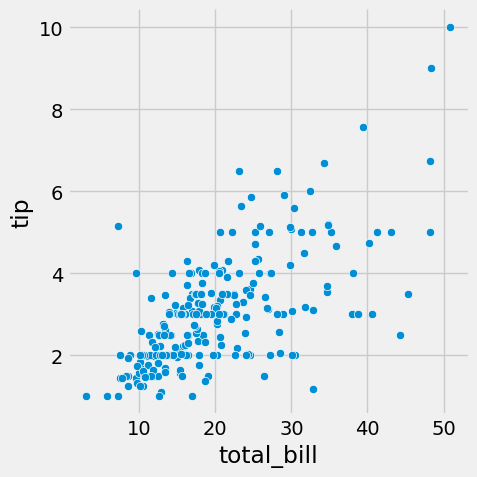

In [9]:
sns.relplot(x = 'total_bill' , y = 'tip', kind='scatter' , data = data)

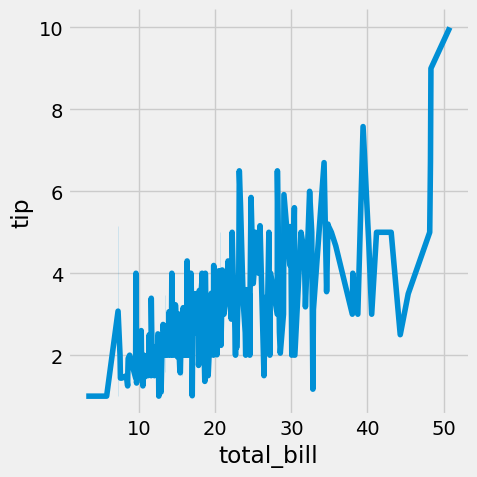

In [10]:
sns.relplot(x = 'total_bill' , y = 'tip', kind='line' , data = data)

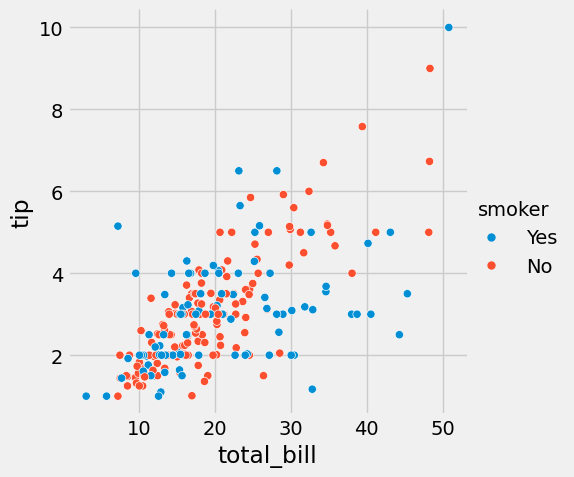

In [12]:
sns.relplot(x= 'total_bill', y='tip' , hue = 'smoker' , data = data )

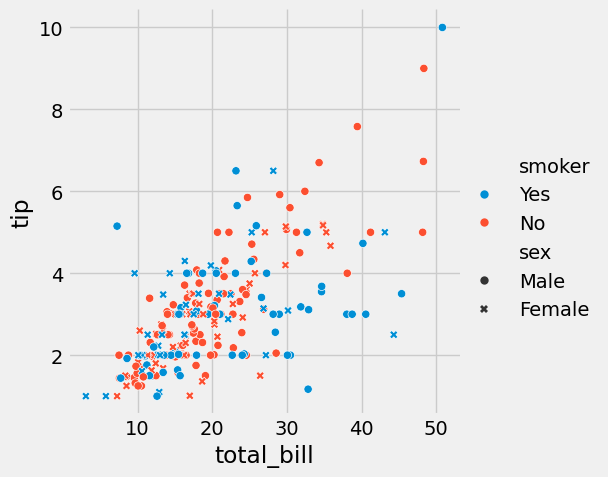

In [14]:
sns.relplot(x= 'total_bill', y='tip' , hue = 'smoker', style = 'sex', data = data )

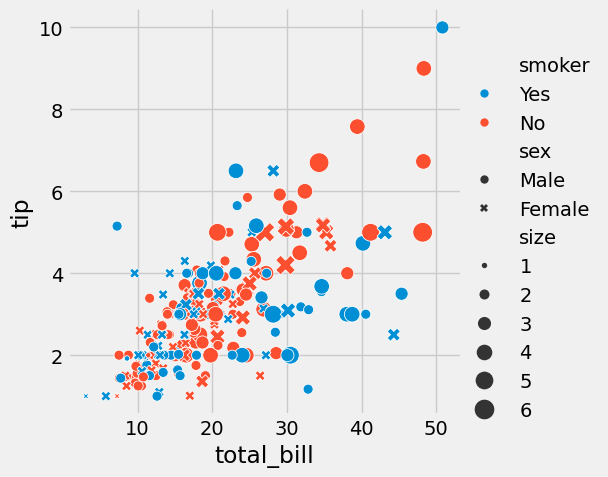

In [18]:
sns.relplot( x= 'total_bill', y='tip' , hue = 'smoker', style = 'sex' ,size = 'size' ,sizes = (15 , 200) , data = data )

<Axes: xlabel='total_bill', ylabel='tip'>

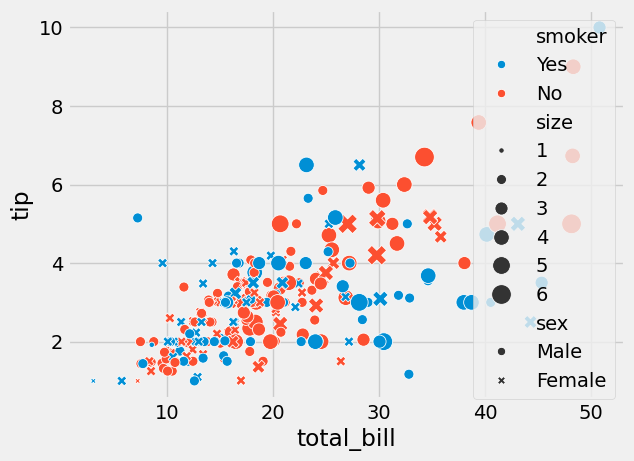

In [20]:
sns.scatterplot(x= 'total_bill', y='tip' , hue = 'smoker', style = 'sex' ,size = 'size' ,sizes = (15 , 200)  , data = data )

In [22]:
data

,total_bill,tip,sex,smoker,day,time,size
0,16.99,1.01,Female,No,Sun,Dinner,2
1,10.34,1.66,Male,No,Sun,Dinner,3
2,21.01,3.50,Male,No,Sun,Dinner,3
3,23.68,3.31,Male,No,Sun,Dinner,2
4,24.59,3.61,Female,No,Sun,Dinner,4
...,...,...,...,...,...,...,...
239,29.03,5.92,Male,No,Sat,Dinner,3
240,27.18,2.00,Female,Yes,Sat,Dinner,2
241,22.67,2.00,Male,Yes,Sat,Dinner,2
242,17.82,1.75,Male,No,Sat,Dinner,2


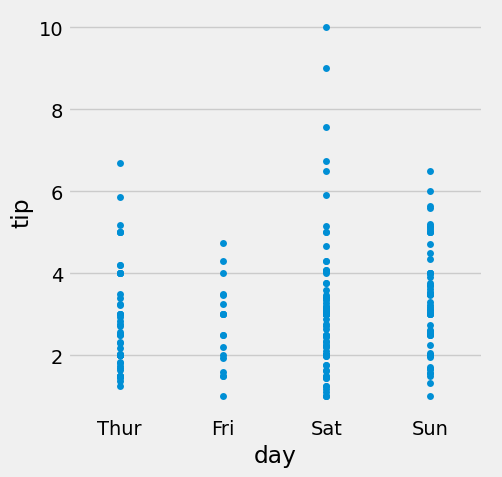

In [31]:
sns.catplot(x='day', y='tip' , kind='strip', jitter = 0 , data = data)

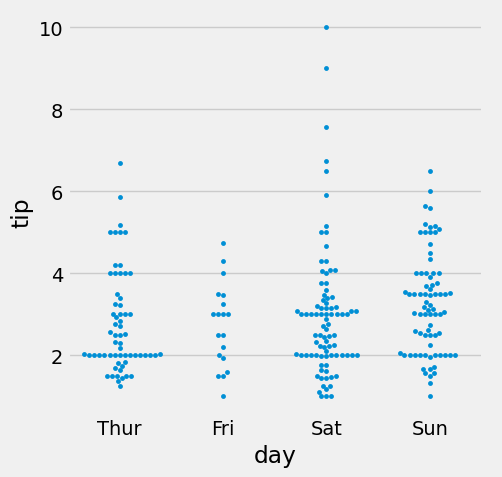

In [39]:
sns.catplot(x='day', y = 'tip', kind = 'swarm', size = 3.5 , data = data)

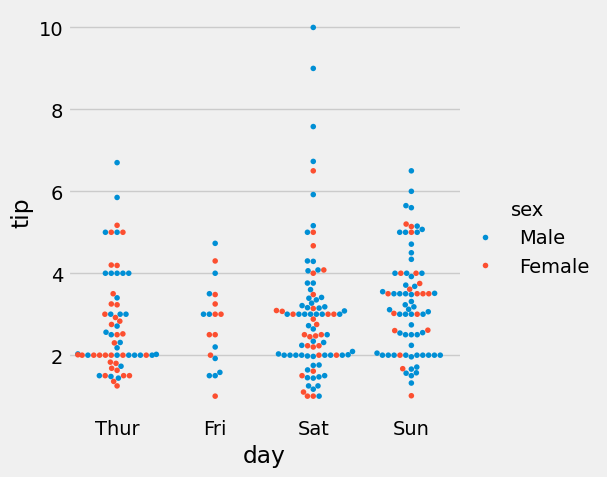

In [43]:
sns.catplot(x = 'day' , y = 'tip' , kind = 'swarm' , size = 4 , hue= 'sex' , data = data )

<Axes: xlabel='day', ylabel='tip'>

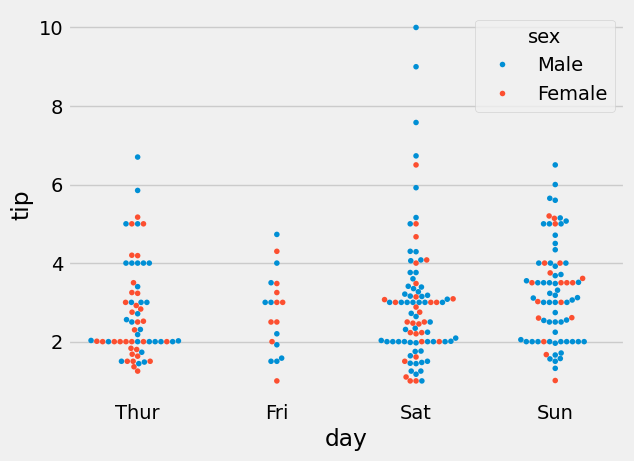

In [46]:
sns.swarmplot(x = 'day' , y = 'tip'  , size = 4 , hue= 'sex' , data = data )

<Axes: ylabel='tip'>

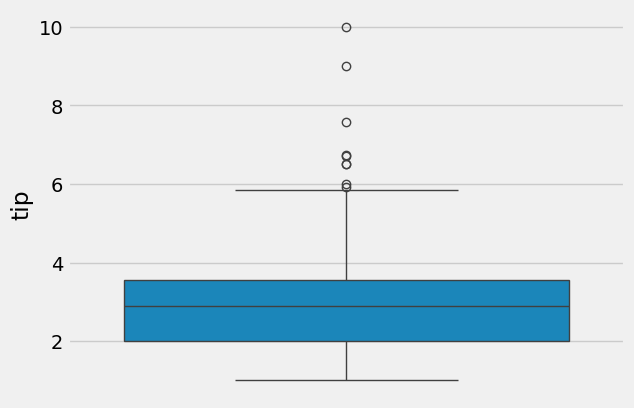

In [47]:
sns.boxplot(data['tip'])

<Axes: ylabel='total_bill'>

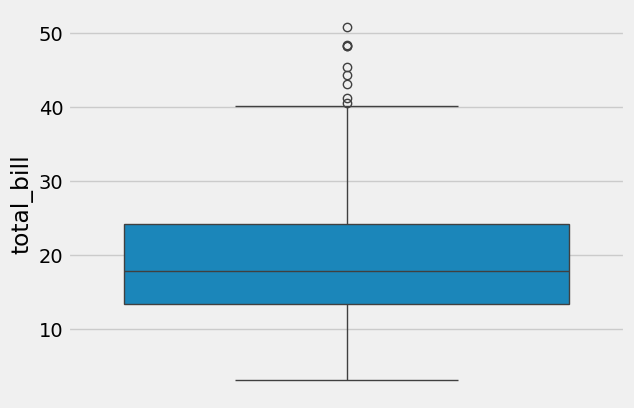

In [49]:
sns.boxplot(data['total_bill'])

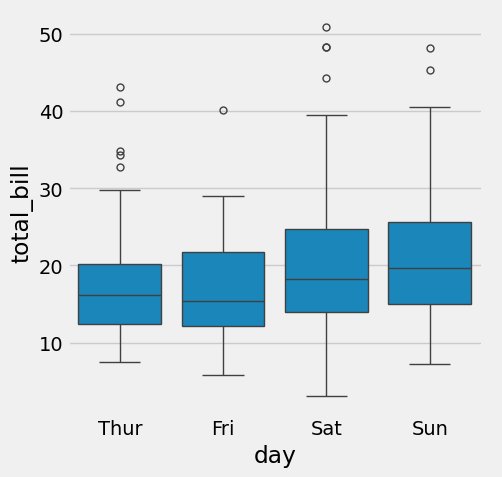

In [50]:
sns.catplot(x = 'day' , y = 'total_bill' , kind = 'box' , data = data)

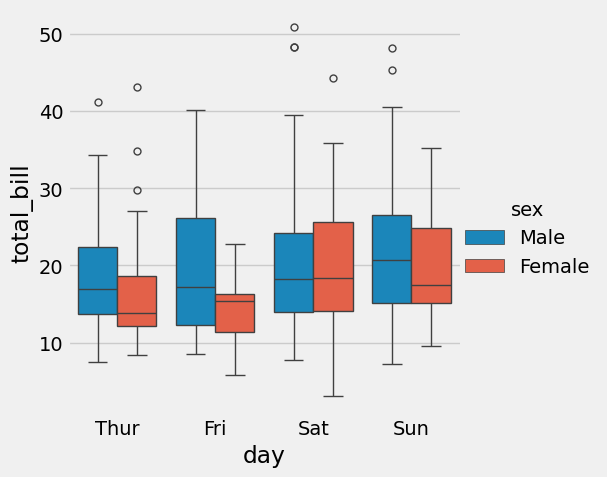

In [54]:
sns.catplot(x='day' , y='total_bill' , hue = 'sex', kind = 'box' , data= data)

<Axes: ylabel='total_bill'>

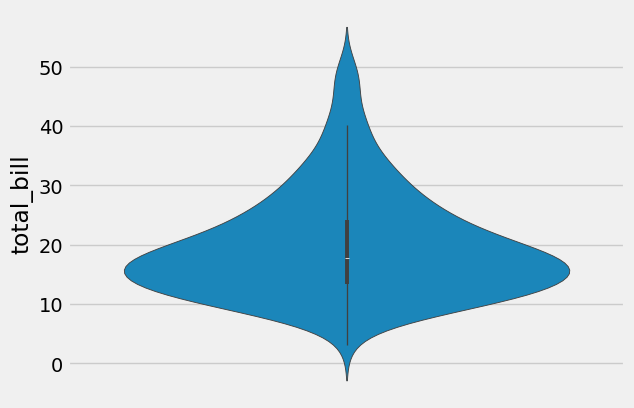

In [57]:
sns.violinplot(data['total_bill'])

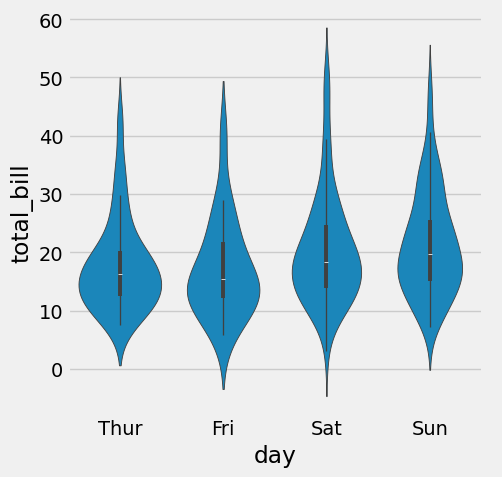

In [58]:
sns.catplot(x = 'day' , y = 'total_bill' , kind = 'violin' , data = data)

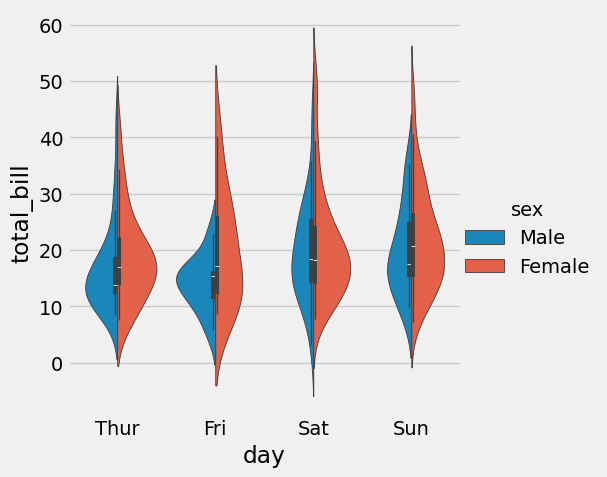

In [60]:
sns.catplot(x = 'day' , y = 'total_bill' , kind = 'violin', hue = 'sex' ,split = True , data = data) 

1. Scatter Plot — sns.scatterplot()

Math relation: Plots raw (x, y) pairs directly — visually represents correlation/covariance between two continuous variables. If points trend upward-right, correlation is positive; downward-right, negative; no pattern, near-zero correlation.

When to use: Two continuous numeric variables, checking for linear/non-linear relationship, clusters, or outliers.

python
sns.scatterplot(data=df, x='revenue', y='ad_spend', hue='region', size='employees', alpha=0.6)

Unique parameters:

hue — encode a 3rd categorical variable as color (e.g., compare correlation across regions)
size — encode a 4th numeric variable as point size
alpha — transparency, critical when points overlap heavily (dense data hides true density otherwise)
2. Strip Plot — sns.stripplot()

Math relation: Essentially a 1D scatter per category — shows every raw data point in its true value along one categorical axis. No aggregation, no summary stats — pure sample distribution.

When to use: Small-to-medium datasets where you want to see individual observations per category, not just a summary (good first look before boxplot/violin).

python
sns.stripplot(data=df, x='language', y='salary', jitter=True, hue='experience_level', dodge=True)

Unique parameters:

jitter — adds random horizontal noise so overlapping points at the same value become visible (without it, identical values stack invisibly on one line)
dodge — separates hue groups side-by-side instead of overlapping them at the same x position
3. Box Plot — sns.boxplot()

Math relation: Directly visualizes the five-number summary: minimum, Q1 (25th percentile), median, Q3 (75th percentile), maximum. Whiskers extend to 1.5 × IQR (IQR = Q3−Q1) by default; anything beyond that is plotted as an outlier point.

When to use: Comparing spread, median, and outliers across categories — best when you care about summary statistics, not distribution shape.

python
sns.boxplot(data=df, x='language', y='salary', whis=1.5, showfliers=True)

Unique parameters:

whis — changes the outlier threshold multiplier (e.g., whis=3 = more lenient, fewer points marked as outliers)
showfliers — toggle outlier points on/off
notch=True — adds a notch around the median showing a rough confidence interval, useful for judging if medians differ significantly between groups
4. Violin Plot — sns.violinplot()

Math relation: Combines boxplot summary stats with a Kernel Density Estimate (KDE) — a smoothed probability density function of the data, mirrored to form the violin shape. Unlike a boxplot, it reveals multimodality (e.g., two peaks) that a box/median alone would hide.

When to use: When distribution shape matters, not just summary stats — e.g., checking if salaries are bimodal (junior vs senior cluster) within one category.

python
sns.violinplot(data=df, x='language', y='salary', hue='experience_level', split=True, inner='quartile', bw_adjust=0.5)

Unique parameters:

split=True — draws two hue groups as mirrored halves of the same violin, for direct shape comparison
inner — what's drawn inside the violin: 'box', 'quartile', 'stick' (raw points), or None
bw_adjust — controls KDE smoothing bandwidth; lower = more detail/wigglier curve, higher = smoother/more generalized shape
5. Line Plot — sns.lineplot()

Math relation: At each x-value, aggregates all corresponding y-values (default: mean) and draws a shaded confidence interval band around it (default: bootstrapped 95% CI) — so it shows both central tendency and uncertainty over an ordered variable, usually time.

When to use: Trends over time or any ordered continuous variable, especially with repeated measurements per x-value (e.g., multiple readings per day).

python
sns.lineplot(data=df, x='month', y='revenue', hue='region', estimator='median', errorbar=('ci', 95))

Unique parameters:

estimator — aggregation function per x (mean, median, sum, or a custom function) — changes what the line actually represents
errorbar — controls the uncertainty band: ('ci', 95) for confidence interval, 'sd' for standard deviation, or None to remove the band entirely
markers=True, style= — adds distinct point markers per line, useful when lines overlap and color alone (hue) isn't enough to distinguish them

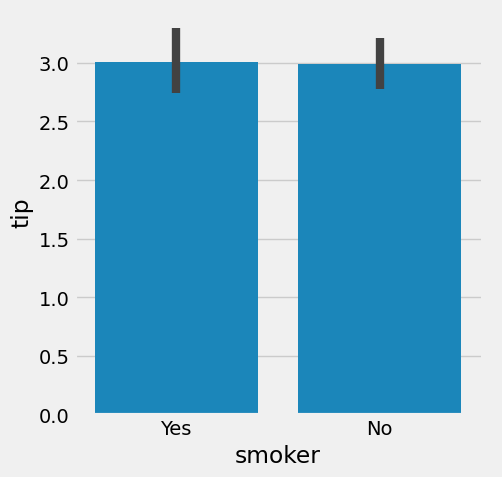

In [61]:
sns.catplot(x = 'smoker' , y = 'tip' , kind = 'bar' , data = data)